<a href="https://colab.research.google.com/github/Honnappa11/CaloriesBurntPrediction-/blob/main/Project_15_Calories_Burnt_Prediction_using_Machine_Learning_with_Pythom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing the Dependencies**

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LinearRegression

**Data Collection and Images**

In [7]:
# converting data into read csv into pandas darta frame
exercies_data=pd.read_csv('/content/exercise.csv')

In [8]:
# print the first 5 rows of the dataframe
exercies_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


In [9]:
# converting data into read csv into pandas data frame
calories=pd.read_csv('/content/calories.csv')

In [10]:
calories.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


**Combining the Two Data Frames**

In [11]:
calories_data=pd.concat([exercies_data,calories['Calories']],axis=1)

In [12]:
calories_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [13]:
# checking  the number of rows and columns
calories_data.shape

(15000, 9)

In [14]:
# checking some information about the data
calories_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [15]:
# checking for missing values
calories_data.isnull().sum()

,0
User_ID,0
Gender,0
Age,0
Height,0
Weight,0
Duration,0
Heart_Rate,0
Body_Temp,0
Calories,0


In [16]:
#  get some statistical measure about the data
calories_data.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


**Data Visualization**

In [17]:

sns.set()

<Axes: xlabel='Gender', ylabel='count'>

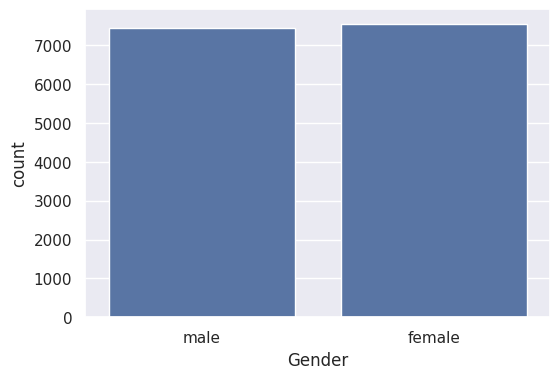

In [18]:
# plotting the gender column in count plot
plt.figure(figsize=(6,4))
sns.countplot(x='Gender',data=calories_data)

<ipython-input-19-2172b72a9895>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(calories_data['Age'],color='green')


<Axes: xlabel='Age', ylabel='Density'>

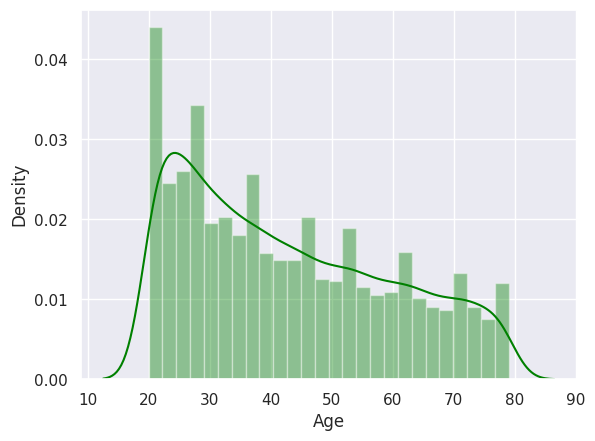

In [19]:
# finding the distribution of 'Age' column
sns.distplot(calories_data['Age'],color='green')

In [20]:
calories_data['Gender'].value_counts()

,count
Gender,
female,7553
male,7447


<ipython-input-21-209812de5885>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(calories_data['Height'],color='red')


<Axes: xlabel='Height', ylabel='Density'>

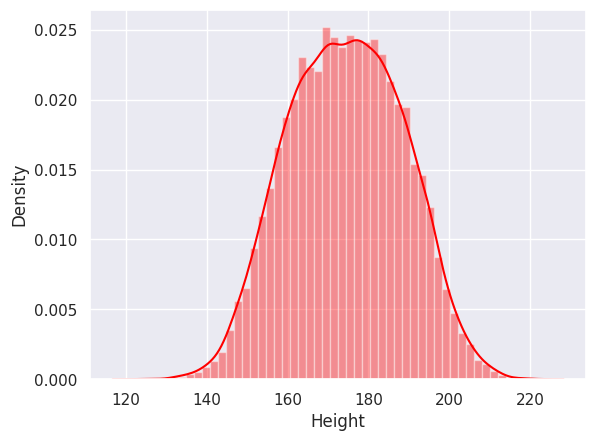

In [21]:
# finding the distribution of 'Weight' column
sns.distplot(calories_data['Height'],color='red')

<ipython-input-22-47dd427b2299>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(calories_data['Weight'],color='violet')


<Axes: xlabel='Weight', ylabel='Density'>

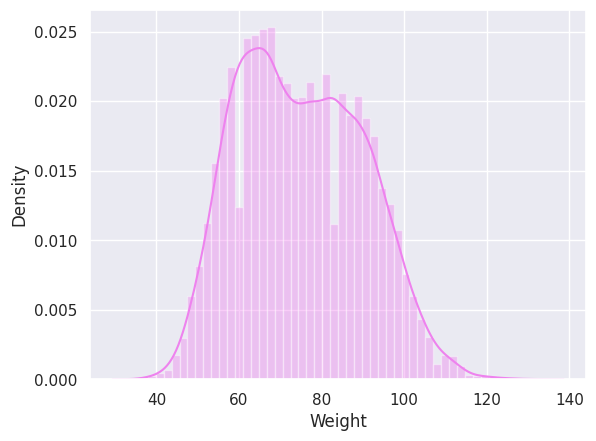

In [22]:
# finding the distribution of 'Weight' column
sns.distplot(calories_data['Weight'],color='violet')

<ipython-input-23-b4d8516987df>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(calories_data['Calories'],color='blue')


<Axes: xlabel='Calories', ylabel='Density'>

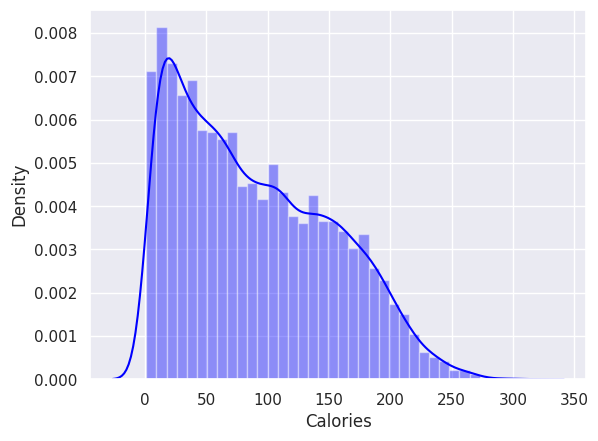

In [23]:
# finding the distribution of 'Calories' column
sns.distplot(calories_data['Calories'],color='blue')

**Converting the text data to numerical values**

In [24]:
calories_data.replace({'Gender':{'male':0,'female':1}},inplace=True)

<ipython-input-24-4ffac1eaf455>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  calories_data.replace({'Gender':{'male':0,'female':1}},inplace=True)


In [25]:
calories_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,0,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,1,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,0,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,1,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,1,27,154.0,58.0,10.0,81.0,39.8,35.0


**Finding the Correlation in the dataset**

**1.Positive Correlation**

**2.Negative Correlation**

In [26]:
correlation=calories_data.corr()

<Axes: >

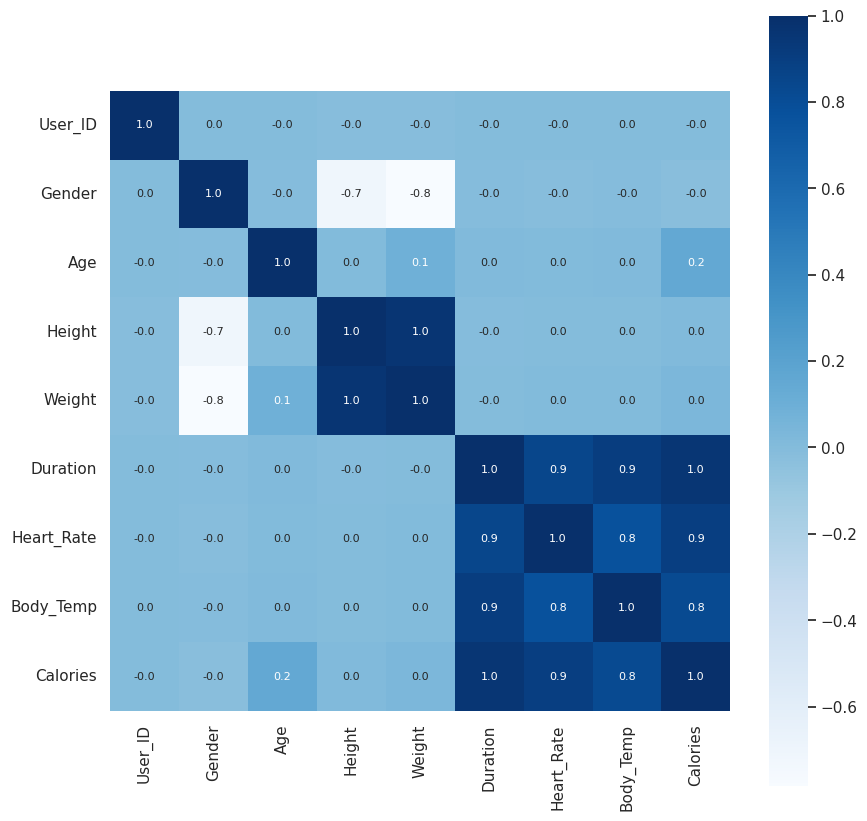

In [27]:
# constructing a heatmap to understand the correlation
plt.figure(figsize=(10,10))
sns.heatmap(correlation,cbar=True,square=True,fmt='.1f',annot=True,annot_kws={'size':8},cmap='Blues')

Seperating the Features and Target

In [28]:
x=calories_data.drop(columns=['User_ID','Calories'],axis=1)
y=calories_data['Calories']

In [29]:
print(x)

       Gender  Age  Height  Weight  Duration  Heart_Rate  Body_Temp
0           0   68   190.0    94.0      29.0       105.0       40.8
1           1   20   166.0    60.0      14.0        94.0       40.3
2           0   69   179.0    79.0       5.0        88.0       38.7
3           1   34   179.0    71.0      13.0       100.0       40.5
4           1   27   154.0    58.0      10.0        81.0       39.8
...       ...  ...     ...     ...       ...         ...        ...
14995       1   20   193.0    86.0      11.0        92.0       40.4
14996       1   27   165.0    65.0       6.0        85.0       39.2
14997       1   43   159.0    58.0      16.0        90.0       40.1
14998       0   78   193.0    97.0       2.0        84.0       38.3
14999       0   63   173.0    79.0      18.0        92.0       40.5

[15000 rows x 7 columns]


In [30]:
print(y)

0        231.0
1         66.0
2         26.0
3         71.0
4         35.0
         ...  
14995     45.0
14996     23.0
14997     75.0
14998     11.0
14999     98.0
Name: Calories, Length: 15000, dtype: float64


**Splitting the data into training data and Test data**

In [31]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [32]:
print(x.shape,x_train.shape,x_test.shape)

(15000, 7) (12000, 7) (3000, 7)


**Model Training**

**Linear Regression**

In [33]:
# loading model
model=LinearRegression()

In [34]:
# training the model with x_train
model.fit(x_train,y_train)

LinearRegression()

**Evaluation**

**Prediction on Test Data**

In [35]:
# prediction on Training data
train_data_prediction = model.predict(x_train)

In [36]:
# R squared Error
error_score = metrics.r2_score(y_train, train_data_prediction)
print("R squared Error : ", error_score)

R squared Error :  0.9672762198112508


**Prediction on Testing Data**

In [37]:
# prediction on Testing data
test_data_prediction = model.predict(x_test)

In [38]:
# R squared Error
error_score = metrics.r2_score(y_test, test_data_prediction)
print("R squared Error : ", error_score)

R squared Error :  0.9668790377181355


**Predictive System**

In [39]:
input_data=(1,20,173.0,77.0,12.0,84.0,39.8)
# converting data into as nparray
input_data_asarray=np.asarray(input_data,dtype=np.float32)
# array as reshaped
input_data_reshaped=input_data_asarray.reshape(1,-1)
predict=model.predict(input_data_reshaped)
print('calories Burnt:',predict)

calories Burnt: [37.38331898]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [40]:
import pickle

In [41]:
filename='calories_trained_data.sav'
pickle.dump(model,open(filename,'wb'))

In [42]:
# loading the saved model
load_model=pickle.load(open('calories_trained_data.sav','rb'))

In [43]:
input_data=(1,20,173.0,77.0,12.0,84.0,39.8)
# converting data into as nparray
input_data_asarray=np.asarray(input_data,dtype=np.float32)
# array as reshaped
input_data_reshaped=input_data_asarray.reshape(1,-1)
predict=load_model.predict(input_data_reshaped)
print('calories Burnt:',predict)

calories Burnt: [37.38331898]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
